In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dir_name = '/content/drive/MyDrive/THESIS/Codes/[Base] CNN-LSTM/Government/'
df = pd.read_csv(f"{dir_name}Government_test_predictions.csv")
df.head()

,Date,Actual,Prediction
0,2020-09-01,255246.0,253341.03
1,2020-10-01,251869.0,251019.73
2,2020-11-01,240289.0,246984.44
3,2020-12-01,237026.0,244973.66
4,2021-01-01,228743.0,242843.75


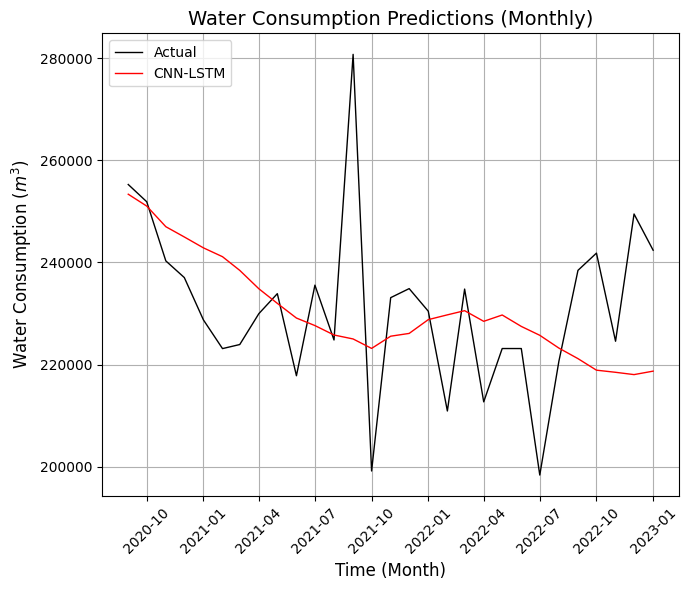

In [ ]:
# Convert 'Date' to datetime for proper labeling
df['Date'] = pd.to_datetime(df['Date'])

# Plot the data
plt.figure(figsize=(7, 6))
plt.plot(df['Date'], df['Actual'], label='Actual', color='black', linewidth=1)
plt.plot(df['Date'], df['Prediction'], label='CNN-LSTM', color='red', linewidth=1)

# Customizing the plot
plt.title('Water Consumption Predictions (Monthly)', fontsize=14)
plt.xlabel('Time (Month)', fontsize=12)
plt.ylabel('Water Consumption ($m^3$)', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True)

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45)

# Display the plot
plt.tight_layout()
plt.show()

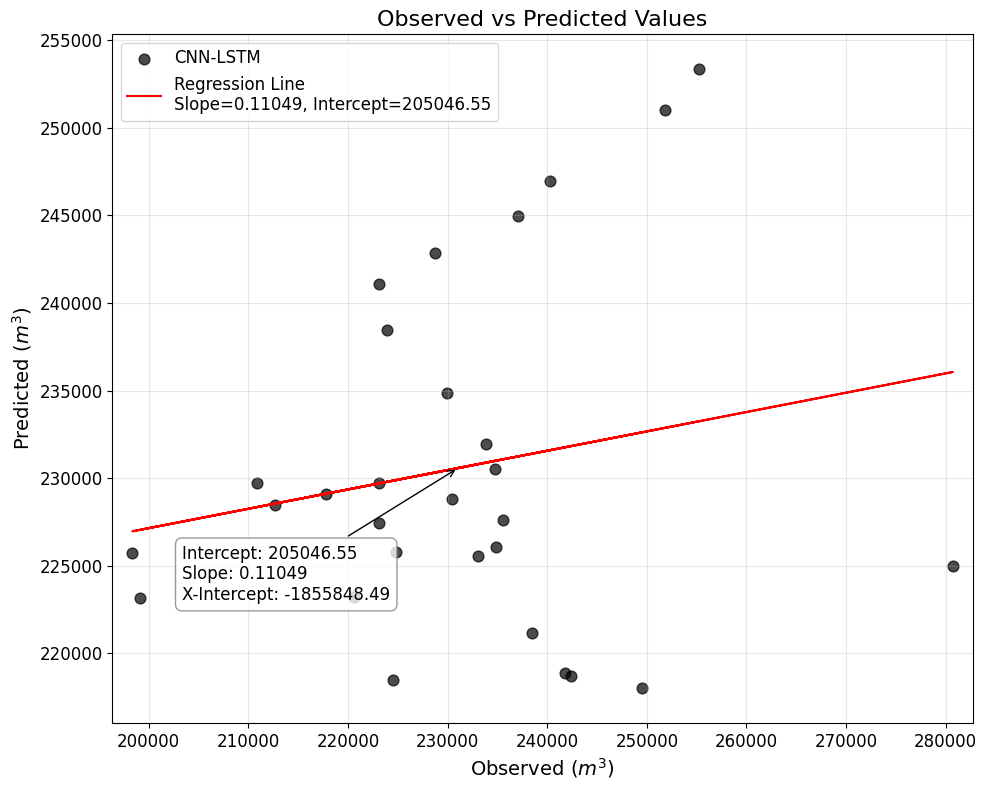

In [8]:
# Extract actual and predicted values
actual = df['Actual']
predicted = df['Prediction']

# Calculate the regression line
slope, intercept = np.polyfit(actual, predicted, 1)
regression_line = slope * actual + intercept

# Create the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(actual, predicted, color='black', label='CNN-LSTM', s=60, alpha=0.7, edgecolors='face')

# Plot the regression line
plt.plot(actual, regression_line, color='red', label=f'Regression Line\nSlope={slope:.5f}, Intercept={intercept:.2f}')

# Add annotations in a clear location
plt.annotate(
    f"Intercept: {intercept:.2f}\nSlope: {slope:.5f}\nX-Intercept: {-intercept / slope:.2f}",
    xy=(actual.mean(), predicted.mean()),
    xytext=(actual.min() + 5000, predicted.min() + 5000),
    fontsize=12,
    color='black',
    bbox=dict(boxstyle="round,pad=0.4", edgecolor="gray", facecolor="white", alpha=0.8),
    arrowprops=dict(arrowstyle="->", color="black")
)

# Disable scientific notation on axes
plt.ticklabel_format(style='plain', axis='both')

# Customizing the plot
plt.title('Observed vs Predicted Values', fontsize=16)
plt.xlabel('Observed ($m^3$)', fontsize=14)
plt.ylabel('Predicted ($m^3$)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(alpha=0.3)

# Dynamically set axis limits to match data
plt.xlim(actual.min() - 2000, actual.max() + 2000)
plt.ylim(predicted.min() - 2000, predicted.max() + 2000)

# Display the improved plot
plt.tight_layout()
plt.show()